<a href="https://colab.research.google.com/github/colab-patricio/studiesIn-systemsAnalysis-Development/blob/main/Gradua%C3%A7%C3%A3o/1st_semester/organizacaoArq_computadores/AF/AF_organizacaoArq_computadores_pratica_chipsNeuromorficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chips Neuromórficos — Prática: Redes Pulsadas em Ação

Organização e arquitetura de computadores - Tema: Chips Neuromórficos (Intel Loihi / IBM TrueNorth)

**Objetivo do notebook:** descrever, na prática, o funcionamento de um chip neuromórfico.

1. **Ato 1 — Rede excitatória/inibitória**: baseada no tutorial `tutorial02_excitatory_inhibitory_network` do [Lava](https://lava-nc.org/index.html) (Intel), reconstruída do zero em NumPy, pois o pacote original foi [arquivado pela Intel](https://github.com/lava-nc/lava) em maio de 2026, assim a gente não depende dele.
2. **Ato 2 — Como converter dígitos em pulsos e reconhecê-los?**: baseada no tutorial *"Optimizing a spiking neural network"* da [NengoDL](https://www.nengo.ai/nengo-dl/), remontada com [snnTorch](https://snntorch.readthedocs.io/en/latest/index.html), mais leve e ainda mantida ativamente.

> Nota: rodar este notebook no Google Colab: o Ato 2 baixa o MNIST e treina mais rápido com GPU.

---
## Ato 1 — Rede Excitatória e Inibitória

Simular, com neurônios do tipo **LIF (Leaky Integrate-and-Fire), como circuitos puramente excitatórios são contra uma rede E/I balanceada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

COLOR_EXC   = "#e76f51"   # laranja = população excitatória
COLOR_INH   = "#457b9d"   # azul    = população inibitória
COLOR_BAL   = "#2a9d8f"   # verde   = cenário balanceado (o "bom")
COLOR_UNBAL = "#e63946"   # vermelho = cenário sem controle (o "caótico")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(7)

# ---- Parâmetros da rede ----------------------------------------------
N_E, N_I = 80, 20          # nº de neurônios excitatórios/inibitórios
N = N_E + N_I
T, dt = 500, 1.0           # passos de simulação (ms)
tau = 15.0                 # constante de tempo da membrana
V_th, V_reset = 1.0, 0.0   # limiar de disparo / valor de reset
refrac_steps = 4           # período refratário

In [2]:
def build_weights(balanced=True, conn_prob=0.15):
    """Constrói a matriz de pesos respeitando a Lei de Dale."""
    W = np.zeros((N, N))
    mask = rng.random((N, N)) < conn_prob
    np.fill_diagonal(mask, False)

    W_E = rng.uniform(0.3, 0.6, size=(N, N_E))
    W_I = rng.uniform(-3.0, -1.5, size=(N, N_I)) if balanced else np.zeros((N, N_I))

    W[:, :N_E] = W_E
    W[:, N_E:] = W_I
    return W * mask


def simulate(W, input_rate=0.06):
    """Simula a rede de neurônios LIF por T passos de tempo."""
    V = np.zeros(N)
    refrac = np.zeros(N, dtype=int)
    spikes = np.zeros((T, N), dtype=bool)

    for t in range(T):
        external_input = rng.poisson(input_rate, N)
        recurrent_input = spikes[t-1].astype(float) @ W.T if t > 0 else np.zeros(N)

        active = refrac <= 0
        V[active] += dt * (-V[active] / tau + external_input[active] + recurrent_input[active])

        fired = active & (V >= V_th)
        spikes[t] = fired
        V[fired] = V_reset
        refrac[fired] = refrac_steps
        refrac[~fired] = np.maximum(refrac[~fired] - 1, 0)

    return spikes


spikes_excit_only = simulate(build_weights(balanced=False))
spikes_balanced   = simulate(build_weights(balanced=True))

print(f"Taxa média de disparo — só excitação:   {spikes_excit_only.mean()*1000:.1f} Hz")
print(f"Taxa média de disparo — E/I balanceado: {spikes_balanced.mean()*1000:.1f} Hz")

Taxa média de disparo — só excitação:   136.6 Hz
Taxa média de disparo — E/I balanceado: 57.7 Hz


### Quem disparou, e quando

O gráfico abaixo é um *raster plot*: cada ponto marca o instante exato em que um neurônio disparou. É a forma mais direta de enxergar a atividade da rede.

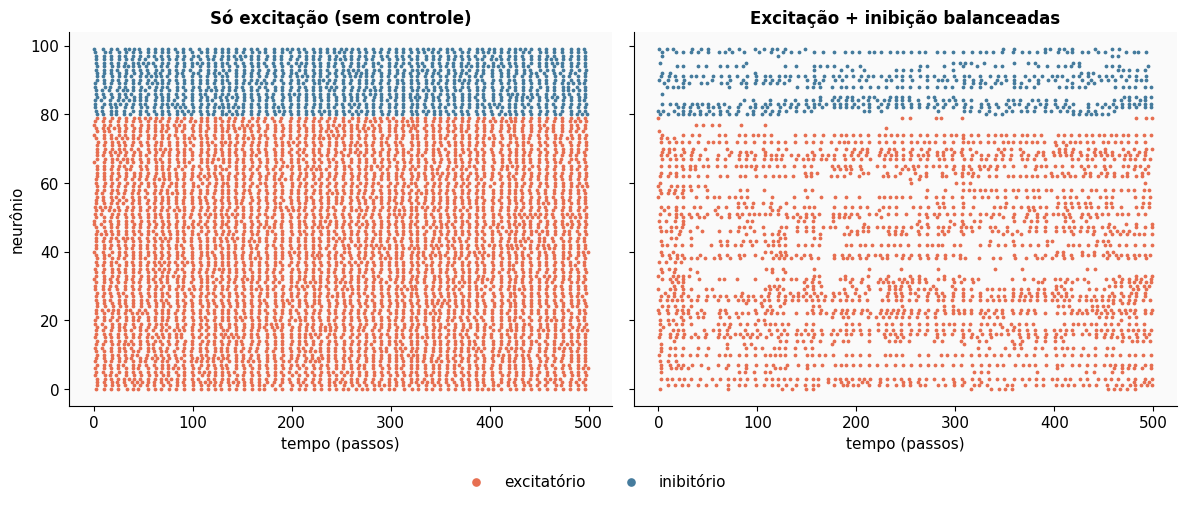

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, spikes, title in zip(
    axes, [spikes_excit_only, spikes_balanced],
    ["Só excitação (sem controle)", "Excitação + inibição balanceadas"]
):
    ts_e, idx_e = np.where(spikes[:, :N_E])
    ts_i, idx_i = np.where(spikes[:, N_E:])
    ax.scatter(ts_e, idx_e, s=3, color=COLOR_EXC, label="excitatório")
    ax.scatter(ts_i, idx_i + N_E, s=3, color=COLOR_INH, label="inibitório")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("tempo (passos)")
axes[0].set_ylabel("neurônio")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           markerscale=3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Repare no contraste antes de qualquer explicação: à esquerda, os pontos praticamente cobrem o gráfico inteiro — quase todos os cem neurônios disparando o tempo todo, em sincronia. À direita, com a inibição entrando em cena, os disparos ficam espalhados e irregulares. Essa "desordem" aparente é, na verdade, a marca de uma rede cortical saudável.

### Panorama geral

Um raster mostra cada neurônio individualmente. Vale agora dar um passo atrás e olhar a atividade da rede como um todo, somando os disparos ao longo do tempo.

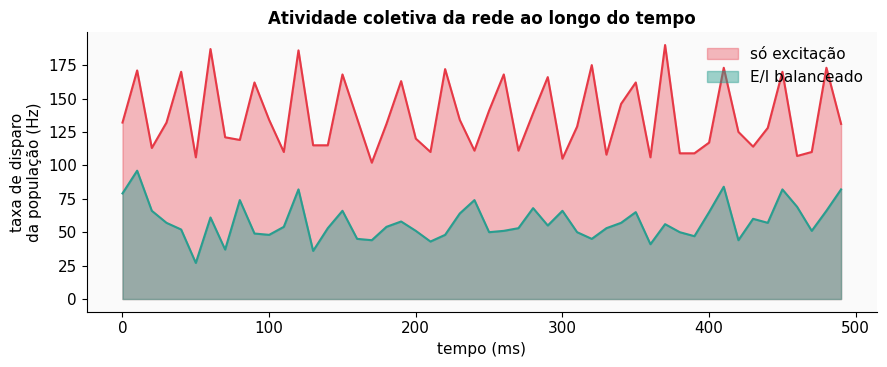

In [4]:
def population_rate(spikes, bin_size=10):
    n_bins = T // bin_size
    trimmed = spikes[:n_bins*bin_size].reshape(n_bins, bin_size, N)
    return trimmed.sum(axis=(1, 2)) / (bin_size * N) * 1000

rate_eo  = population_rate(spikes_excit_only)
rate_bal = population_rate(spikes_balanced)
x = np.arange(len(rate_eo)) * 10

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.fill_between(x, rate_eo, color=COLOR_UNBAL, alpha=0.35, label="só excitação")
ax.plot(x, rate_eo, color=COLOR_UNBAL, linewidth=1.5)
ax.fill_between(x, rate_bal, color=COLOR_BAL, alpha=0.45, label="E/I balanceado")
ax.plot(x, rate_bal, color=COLOR_BAL, linewidth=1.5)
ax.set_xlabel("tempo (ms)")
ax.set_ylabel("taxa de disparo\nda população (Hz)")
ax.set_title("Atividade coletiva da rede ao longo do tempo", fontsize=12, fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Contando quantos disparos ocorreram

Em um chip de verdade, cada disparo custa energia. Então vale contar: do início ao fim da simulação, quantos disparos aconteceram em cada cenário?

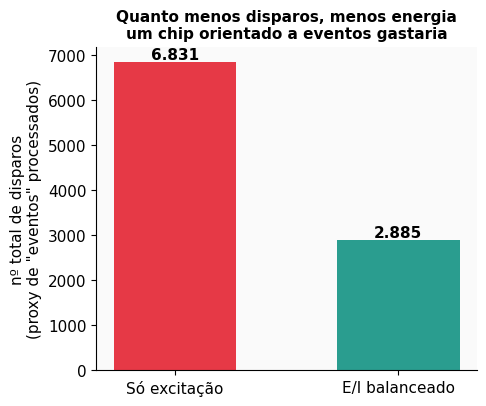

Redução de disparos com a inibição balanceada: 58%


In [5]:
total_eo  = spikes_excit_only.sum()
total_bal = spikes_balanced.sum()

fig, ax = plt.subplots(figsize=(5, 4.2))
bars = ax.bar(["Só excitação", "E/I balanceado"], [total_eo, total_bal],
              color=[COLOR_UNBAL, COLOR_BAL], width=0.55)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f"{int(h):,}".replace(",", "."),
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel('nº total de disparos\n(proxy de "eventos" processados)')
ax.set_title("Quanto menos disparos, menos energia\num chip orientado a eventos gastaria",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

reducao = 100 * (1 - total_bal / total_eo)
print(f"Redução de disparos com a inibição balanceada: {reducao:.0f}%")

A rede balanceada precisou de **58% menos disparos** para existir pelo mesmo período de tempo e sem perder capacidade de resposta. É exatamente esse tipo de economia que motiva um chip como o Loihi ou o TrueNorth: cada evento custa energia real em silício, então quanto menos eventos desnecessários, melhor.

---
## Ato 2 — De um traço de lápis a uma decisão

Se no Ato 1 a pergunta era sobre estabilidade, aqui ela muda: será que dá para ensinar algo tão "tudo ou nada" quanto um neurônio pulsado a reconhecer um dígito escrito à mão?

O empecilho é técnico: treinar redes neurais depende de gradientes suaves, e um disparo é uma função em degrau — dispara ou não dispara, sem meio-termo. A saída, usada tanto pela NengoDL quanto pelo snnTorch, é um pequeno "blefe" matemático chamado **gradiente substituto**: durante o treino, a rede finge que o disparo tem uma curva suave só para poder calcular como ajustar os pesos; na hora de rodar de verdade, o disparo continua sendo real, tudo ou nada.

In [6]:
# Rode esta célula uma vez (no Colab, ou no seu ambiente local)
!pip install -q snntorch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 4.7 MB/s eta 0:00:00


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import snntorch as snn
from snntorch import utils, surrogate, spikegen
from snntorch import functional as SF
import matplotlib.pyplot as plt
import numpy as np

# mesma paleta do Ato 1, redefinida aqui para o caso de rodar este trecho isoladamente
COLOR_BAL = "#2a9d8f"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

Usando: cuda


### Sobre o dataset

> O conjunto de dados **[MNIST](https://huggingface.co/datasets/ylecun/mnist)** consiste em **70.000 imagens em preto e branco, com dimensões de 28 × 28 pixels**, contendo dígitos manuscritos extraídos de dois bancos de dados do **NIST**. Há **60.000 imagens no conjunto de treinamento** e **10.000 imagens no conjunto de validação/teste**, sendo uma classe para cada dígito, totalizando **10 classes**. Cada classe possui **7.000 imagens** (**6.000 imagens de treinamento e 1.000 imagens de teste**).
>
> Metade das imagens foi desenhada por **funcionários do Census Bureau** e a outra metade por **estudantes do ensino médio**. Essa divisão é distribuída igualmente entre os conjuntos de treinamento e de teste.

O dataset é comumente usado como um benchmark para tarefas de classificação de imagens em algoritmos de *Machine Learning*


In [8]:
# ---- Dados ------------------------------------------------------------------------------
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])
data_path = "./data/mnist"

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST(data_path, train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader  = DataLoader(mnist_test, batch_size=batch_size, shuffle=False, drop_last=True)

num_steps = 25   # nº de passos de tempo simulados por imagem

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.99MB/s]


### Como uma imagem vira uma sequência de pulsos

Antes de entrar na rede propriamente dita, vale ver a transformação mais básica de todas: como um pixel — um número entre 0 e 1 — vira uma sequência de disparos ao longo do tempo.

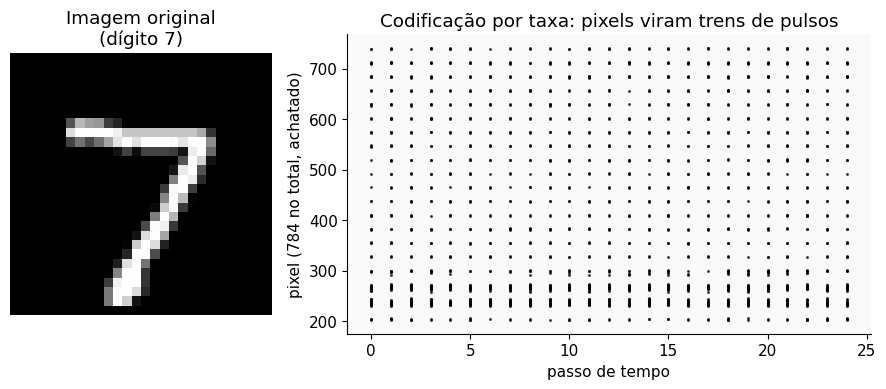

In [9]:
# pega um dígito de teste para ilustrar a codificação
data_iter = iter(test_loader)
sample_data, sample_targets = next(data_iter)
sample_img, sample_label = sample_data[0:1], sample_targets[0].item()

# codificação por taxa: quanto mais claro o pixel, mais provável ele "disparar" a cada passo
spike_input = spikegen.rate(sample_img.view(1, -1), num_steps=num_steps)  # (num_steps, 1, 784)
raster = spike_input.squeeze(1).numpy()
ts, px = np.where(raster)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={"width_ratios": [1, 2]})
axes[0].imshow(sample_img.squeeze().numpy(), cmap="gray")
axes[0].set_title(f"Imagem original\n(dígito {sample_label})")
axes[0].axis("off")
axes[1].scatter(ts, px, s=1.5, color="black", alpha=0.6)
axes[1].set_xlabel("passo de tempo")
axes[1].set_ylabel("pixel (784 no total, achatado)")
axes[1].set_title("Codificação por taxa: pixels viram trens de pulsos")
plt.tight_layout()
plt.show()

No exemplo rodado acima, o dígito era um 7: repare como as regiões escuras do fundo (pixels próximos de zero) quase não geram disparos, enquanto a faixa que desenha o traço do número aparece como uma sequência praticamente contínua de pontos. A imagem inteira foi reescrita na única linguagem que um neurônio pulsado entende: 0 ou 1.

In [10]:
# ---- Definição da rede pulsada ------------------------------------------------------------
beta = 0.9                                 # taxa de decaimento do neurônio (o "vazamento")
spike_grad = surrogate.fast_sigmoid()      # gradiente substituto

net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
    nn.Linear(128, 10),
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output=True),
).to(device)

In [11]:
def forward_pass(net, data, num_steps):
    spk_rec = []
    utils.reset(net)  # zera os potenciais de membrana no início de cada imagem
    for _ in range(num_steps):
        spk_out, _ = net(data)
        spk_rec.append(spk_out)
    return torch.stack(spk_rec)


def accuracy(loader, net, num_steps, n_batches=20):
    net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i, (data, targets) in enumerate(loader):
            if i >= n_batches:
                break
            data, targets = data.to(device), targets.to(device)
            spk_rec = forward_pass(net, data, num_steps)
            _, predicted = spk_rec.sum(dim=0).max(dim=1)
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
    return 100 * correct / total

In [12]:
print(f"Acurácia ANTES do treino: {accuracy(test_loader, net, num_steps):.1f}%  (esperado: ~10%, chute aleatório)")

Acurácia ANTES do treino: 6.8%  (esperado: ~10%, chute aleatório)


### Assistindo a rede aprender

Com a rede definida, resta treiná-la. A cada lote de imagens vamos guardar o valor do erro (loss), só para poder desenhar a curva de aprendizado depois.

In [13]:
# ---- Treinamento (coletando o histórico de loss para plotar depois) ----
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
loss_fn = SF.ce_rate_loss()
loss_hist = []

num_epochs = 1  # aumente para 3-5 se tiver tempo/GPU
net.train()
for epoch in range(num_epochs):
    for i, (data, targets) in enumerate(train_loader):
        data, targets = data.to(device), targets.to(device)
        spk_rec = forward_pass(net, data, num_steps)
        loss = loss_fn(spk_rec, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_hist.append(loss.item())

        if i % 100 == 0:
            print(f"epoch {epoch} | batch {i} | loss {loss.item():.3f}")

epoch 0 | batch 0 | loss 2.307
epoch 0 | batch 100 | loss 1.641
epoch 0 | batch 200 | loss 1.537
epoch 0 | batch 300 | loss 1.534
epoch 0 | batch 400 | loss 1.533


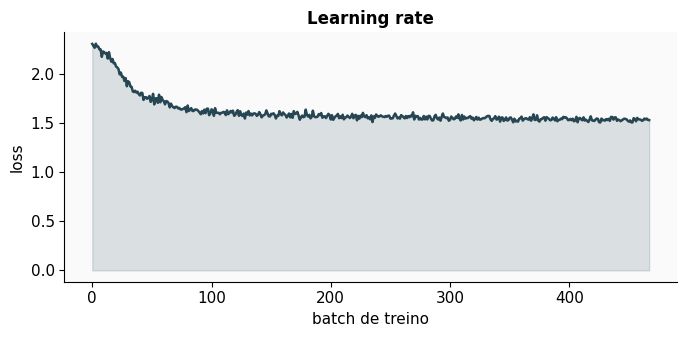

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(loss_hist, color="#264653", linewidth=1.8)
ax.fill_between(range(len(loss_hist)), loss_hist, color="#264653", alpha=0.15)
ax.set_xlabel("batch de treino")
ax.set_ylabel("loss")
ax.set_title("Learning rate", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
print(f"Acurácia DEPOIS do treino: {accuracy(test_loader, net, num_steps):.1f}%")

Acurácia DEPOIS do treino: 92.3%


### Onde a rede acerta — e onde ela hesita

Acurácia é um número só; a matriz de confusão mostra o quadro completo: para cada dígito real, o que a rede respondeu.

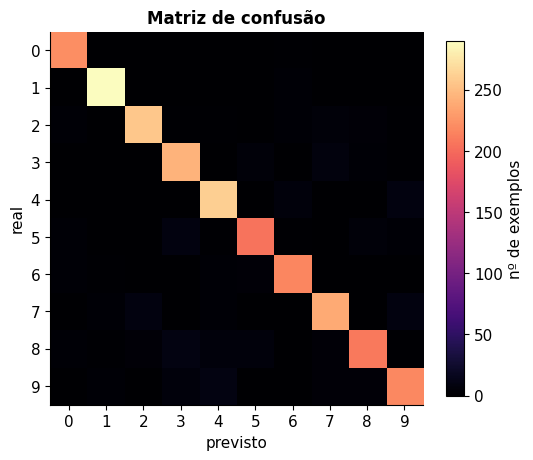

In [16]:
def get_predictions(loader, net, num_steps, n_batches=20):
    net.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for i, (data, targets) in enumerate(loader):
            if i >= n_batches:
                break
            data, targets = data.to(device), targets.to(device)
            spk_rec = forward_pass(net, data, num_steps)
            _, predicted = spk_rec.sum(dim=0).max(dim=1)
            all_preds.append(predicted.cpu())
            all_targets.append(targets.cpu())
    return torch.cat(all_preds).numpy(), torch.cat(all_targets).numpy()

preds, targs = get_predictions(test_loader, net, num_steps)
conf = np.zeros((10, 10), dtype=int)
for p, y in zip(preds, targs):
    conf[y, p] += 1

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(conf, cmap="magma")
ax.set_xlabel("previsto")
ax.set_ylabel("real")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_title("Matriz de confusão", fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="nº de exemplos")
plt.tight_layout()
plt.show()

Com uma única época de treino, a rede chegou a **~92% de acurácia**. A diagonal bem forte da matriz confirma isso visualmente. Os poucos pontos fora da diagonal mostram as confusões mais comuns (4 com 9, por exemplo)

### A decisão, em câmera lenta

Diferente de uma rede tradicional, que responde tudo de uma vez, uma rede pulsada acumula evidência a cada passo de tempo. Dá para literalmente assistir a essa decisão sendo tomada.

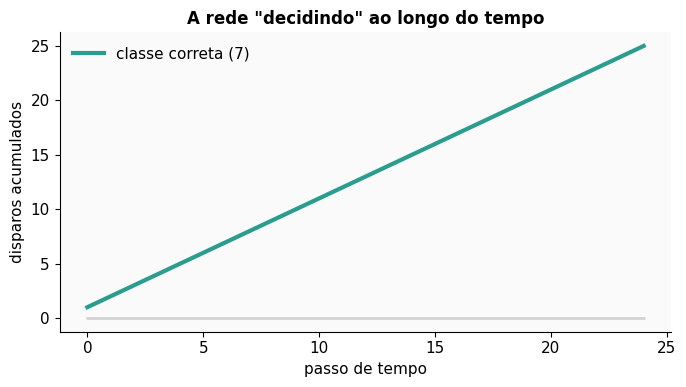

In [17]:
net.eval()
with torch.no_grad():
    spk_rec = forward_pass(net, sample_img.to(device), num_steps)
acumulado = spk_rec.squeeze(1).cumsum(dim=0).cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 4))
for classe in range(10):
    if classe == sample_label:
        continue
    ax.plot(acumulado[:, classe], color="lightgray", linewidth=1)
ax.plot(acumulado[:, sample_label], color=COLOR_BAL, linewidth=3,
        label=f"classe correta ({sample_label})")
ax.set_xlabel("passo de tempo")
ax.set_ylabel("disparos acumulados")
ax.set_title('A rede "decidindo" ao longo do tempo', fontsize=12, fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

No dígito 7 rodado aqui, o resultado não podia ser mais claro: a curva verde sobe de forma quase perfeitamente linear até 25, enquanto as outras nove classes ficam achatadas em zero. Em exemplos mais difíceis (dígitos parecidos, escrita ambígua), é comum ver duas ou três curvas disputando antes que uma se destaque.

---
## Fechando o círculo: de volta ao silício

As duas simulações acima rodaram inteiramente em CPU/GPU comuns — nenhum chip neuromórfico de verdade foi usado, mas o comportamento reproduzido aqui é exatamente o que acontece, fisicamente, dentro de um chip como o Loihi ou o TrueNorth. E é no consumo de energia que essa diferença de paradigma fica mais gritante:

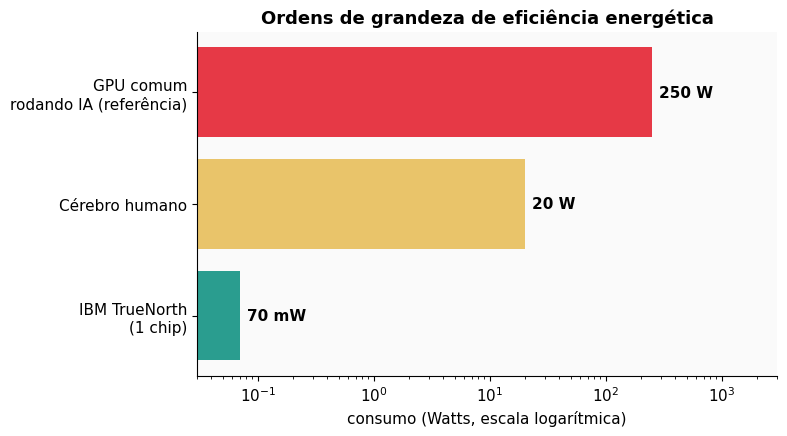

In [18]:
labels = ["IBM TrueNorth\n(1 chip)", "Cérebro humano", "GPU comum\nrodando IA (referência)"]
watts = [0.07, 20, 250]
colors = ["#2a9d8f", "#e9c46a", "#e63946"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(labels, watts, color=colors)
ax.set_xscale("log")
ax.set_xlabel("consumo (Watts, escala logarítmica)")
ax.set_title("Ordens de grandeza de eficiência energética", fontsize=13, fontweight="bold")
for bar, w in zip(bars, watts):
    label = f"{w} W" if w >= 1 else f"{int(w*1000)} mW"
    ax.text(bar.get_width()*1.15, bar.get_y() + bar.get_height()/2, label,
            va="center", fontsize=11, fontweight="bold")
ax.set_xlim(0.03, 3000)
plt.tight_layout()
plt.show()

Uma nota honesta: os valores de GPU e cérebro aqui servem como referência de ordem de grandeza, não como um benchmark rodando exatamente a mesma tarefa nas mesmas condições. Mesmo assim, a escala da diferença já fala por si.